# 06 · Reanalysis: position scale, AC sensitivity, channel decomposition, uncertainty

Pure analysis — no instrument. Runs off the saved `.npz` / `.csv` / `FAMap*.ibw`
files, so it can be re-executed any time without microscope access.

Four things, each of which changed a conclusion:

1. **Position scale.** `DoLDMove` under-delivers on small steps. A dense sweep of
   0.5 µm steps travelled only 85% of its commanded span (Demo6); at 1.0 µm the
   error is ~2%. `fit_position_scale` recovers it from the InvOLS the run already
   logs.
2. **AC sensitivity.** The tune amplitude must be converted with `AmpInvOLS`,
   which is `InvOLS / 32.0` — not the DC `InvOLS`. Detection is interferometric
   (displacement), so `1/InvOLS` follows the end-loaded shape x²(3L−x), not the
   beam-deflection slope form.
3. **Channel decomposition.** `a = Z(V=0) = P − S·V_cpd` still carries
   electrostatics. Solving for the `V_cpd` that makes d_eff position-independent
   gives both at once.
4. **Uncertainty.** The reconstruction sits at the run-to-run reproducibility
   floor; the reported `std` under-reports by ~3× because it cannot see that term.

In [1]:
import os, sys, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq

# --- where the data and the package live -----------------------------------
ROOTS = [os.environ.get('AMM_DATA', ''),
         r'D:\User Data\Liam\ActiveModeMap']
PKGS  = [os.environ.get('AMM_PKG', ''),
         r'C:\Users\Asylum User\Desktop\STAFF Software\Liam\ActiveModeMap']
ROOT = next(p for p in ROOTS if p and os.path.isdir(p))
PKG  = next(p for p in PKGS  if p and os.path.isdir(p))
sys.path.insert(0, PKG)
from activemodemap.lowrank import reconstruct_map, LowRankModeMap, band_mask, resonance_index
from activemodemap.online import fit_position_scale, PositionScale

DENSE = os.path.join(ROOT, 'SCM_PIT', 'Dense_Grid_A')
BIAS  = os.path.join(ROOT, 'SCM_PIT', 'Bias Dependence')
DEMO6 = os.path.join(ROOT, 'Demo6Fullgrid')
AC_DIVISOR = 32.0                      # AmpInvOLS = InvOLS / AC_DIVISOR
BAND_A = (270e3, 450e3)                # mode A: resonance + its antiresonance excursion
BAND_B = (860e3, 1300e3)               # mode B
print('data :', ROOT); print('pkg  :', PKG)
for p in (DENSE, BIAS, DEMO6):
    print(f'  {"OK " if os.path.isdir(p) else "MISSING"} {p}')

def read_log(path):
    d = pd.read_csv(path)
    if 'tune_file' in d:
        d['idx'] = d.tune_file.str.extract(r'_(\d{4})\.txt').astype(int)
    return d

def measured_invols(ibw):
    """Recompute InvOLS from a force curve. Do NOT read it from the note: the
    panel value is written AFTER the curve, so a note carries the PREVIOUS
    position's value — up to 60% wrong in a jumping-order series."""
    from igor2 import binarywave
    w = binarywave.load(ibw)['wave']; W = w['wData'].astype(float)
    note = str(w['note']); curr = float(note.split('rInvOLS: ')[1].split('\\')[0])
    z, de = W[:, 4], W[:, 1]
    mi = int(np.argmax(de)); e = int(np.argmin(de[:mi])); di = mi - e
    i1, i2 = int(e + .25*di), int(mi - .25*di)
    dV = de / curr
    return (z[i2] - z[i1]) / (dV[i2] - dV[i1])

data : /mnt/user-data/uploads/User Data--Liam--ActiveModeMap
pkg  : /home/claude/work/pkg
  OK  /mnt/user-data/uploads/User Data--Liam--ActiveModeMap/SCM_PIT/Dense_Grid_A
  OK  /mnt/user-data/uploads/User Data--Liam--ActiveModeMap/SCM_PIT/Bias Dependence
  OK  /mnt/user-data/uploads/User Data--Liam--ActiveModeMap/Demo6Fullgrid


## 1 · Position scale

`fit_position_scale` matches the two passes' InvOLS-vs-position curves. InvOLS is
a steep monotonic function of true spot position and is logged at every position
of every pass, so it is a free position ruler.

In [2]:
log = read_log(os.path.join(DENSE, 'DenseReference_log.csv'))
sp, dn = log[log.idx <= 19], log[log.idx >= 20]
ps = fit_position_scale(sp, dn)
xm_ = np.array([m[0] for m in ps.matched]); n_ = len(xm_)
se = np.sqrt(np.sum(ps.resid_um**2)/(n_-2)/np.sum((xm_-xm_.mean())**2))
span = dn.position_x_um.max() - dn.position_x_um.min()
print(f'\nDense_Grid_A (1.0 um pitch): scale {ps.scale:.4f} +- {se:.4f}, '
      f'axis error {abs((1-ps.scale)*span):.2f} um over {span:.0f} um')

if os.path.isdir(DEMO6):                       # 0.5 um pitch, for contrast
    l6 = read_log(os.path.join(DEMO6, 'DenseReference_log.csv'))
    ps6 = fit_position_scale(l6[l6.idx <= 8], l6[l6.idx >= 9], verbose=False)
    s6 = l6[l6.idx >= 9].position_x_um
    print(f'Demo6Fullgrid (0.5 um pitch): scale {ps6.scale:.4f}, '
          f'axis error {abs((1-ps6.scale)*(s6.max()-s6.min())):.1f} um')
    print('\n-> 1 um pitch is safe; 0.5 um is not (DoLDMove dead-band).')

  position scale from InvOLS: PositionScale(scale=1.0244, offset=-4.73um, source=invols, n=19, rms=0.60um)
    dense axis is compressed -2.4% — its span is really 102.4 um, not 100.0 um
    excluded [125.] um (InvOLS outside the dense pass's range -> never actually covered by it)

Dense_Grid_A (1.0 um pitch): scale 1.0244 +- 0.0043, axis error 2.44 um over 100 um
Demo6Fullgrid (0.5 um pitch): scale 0.8466, axis error 21.5 um

-> 1 um pitch is safe; 0.5 um is not (DoLDMove dead-band).


## 2 · Sensitivity: interferometric, and AC = DC / 32

Two checks. `1/InvOLS` should follow the **displacement** shape x²(3L−x) for an
interferometer (the slope form s(2L−s) is for beam deflection). And `AmpInvOLS`
in every note is exactly `InvOLS/32` — a fixed AC-path gain.

displacement x^2(3L-x)  residual 0.33%   L = 246.2 um   <- interferometer
slope        x(2L-x)    residual 0.95%

fitted L = 246.2 um vs a 225 um lever -> label->true scale 0.914



InvOLS / AmpInvOLS in the notes:
  FAMapS0001.ibw:   507.63 / 15.863 nm/V = 32.0009
  FAMapS0003.ibw:   528.59 / 16.519 nm/V = 31.9989
  FAMapS0005.ibw:   766.99 / 23.968 nm/V = 32.0006
  FAMapS0007.ibw:   766.99 / 23.968 nm/V = 32.0006
  FAMapS0009.ibw:   766.99 / 23.968 nm/V = 32.0006
  FAMapS0011.ibw:   592.72 / 18.522 nm/V = 32.0009
  FAMapS0013.ibw:   477.65 / 14.927 nm/V = 31.9991
  FAMapS0015.ibw:   477.65 / 14.927 nm/V = 31.9991
  mean ratio 32.0001  -> AC_DIVISOR = 32.0


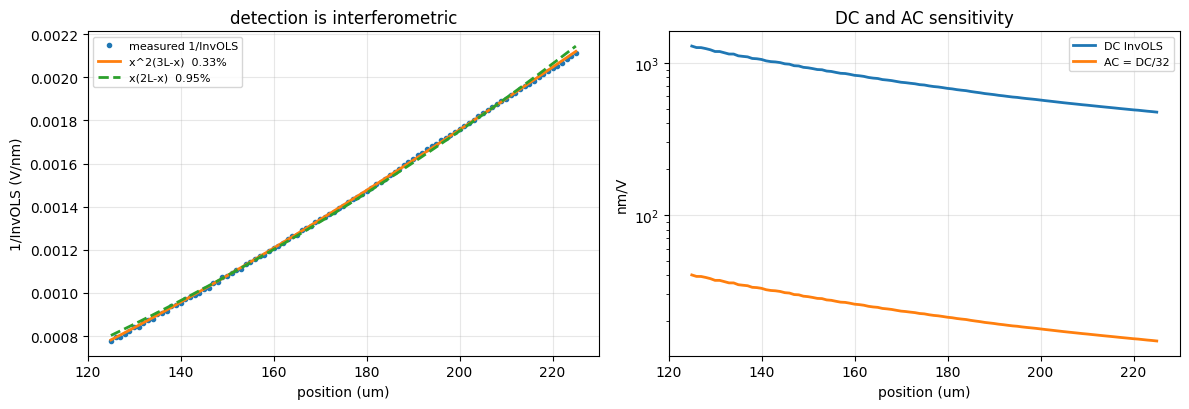

In [3]:
X = dn.position_x_um.values; S = 1/dn.invols_m_per_V.values
disp  = lambda x, c, L: c*x**2*(3*L - x)
slope = lambda x, c, L: c*x*(2*L - x)
# both shapes are linear in their two coefficients, so solve them exactly
# displacement: S = A x^2 + B x^3  with A = 3cL, B = -c   -> L = -A/(3B)
A2 = np.column_stack([X**2, X**3]); cA, *_ = np.linalg.lstsq(A2, S, rcond=None)
pd_ = (-cA[1], -cA[0]/(3*cA[1]))
# slope:        S = A x   + B x^2  with A = 2cL, B = -c   -> L = -A/(2B)
A1 = np.column_stack([X, X**2]);    cB, *_ = np.linalg.lstsq(A1, S, rcond=None)
ps_ = (-cB[1], -cB[0]/(2*cB[1]))
rd = 100*np.std(S - disp(X, *pd_))/S.mean(); rs = 100*np.std(S - slope(X, *ps_))/S.mean()
print(f'displacement x^2(3L-x)  residual {rd:.2f}%   L = {pd_[1]:.1f} um   <- interferometer')
print(f'slope        x(2L-x)    residual {rs:.2f}%')
print(f'\nfitted L = {pd_[1]:.1f} um vs a {225} um lever -> label->true scale {225/pd_[1]:.3f}')

from igor2 import binarywave
rows = []
for f in sorted(glob.glob(os.path.join(BIAS, 'FAMapS*.ibw')))[:8]:
    n = binarywave.load(f)['wave']['note']; s = str(n)
    dc = float(s.split('rInvOLS: ')[1].split('\\')[0])
    ac = float(s.split('rAmpInvOLS: ')[1].split('\\')[0])
    rows.append((os.path.basename(f), dc, ac, dc/ac))
print('\nInvOLS / AmpInvOLS in the notes:')
for f, dc, ac, r in rows: print(f'  {f}: {dc*1e9:8.2f} / {ac*1e9:6.3f} nm/V = {r:.4f}')
print(f'  mean ratio {np.mean([r[3] for r in rows]):.4f}  -> AC_DIVISOR = {AC_DIVISOR}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
xx = np.linspace(X.min(), X.max(), 300)
ax[0].plot(X, S*1e-9, 'o', ms=3, label='measured 1/InvOLS')
ax[0].plot(xx, disp(xx, *pd_)*1e-9, '-', lw=2, label=f'x^2(3L-x)  {rd:.2f}%')
ax[0].plot(xx, slope(xx, *ps_)*1e-9, '--', lw=2, label=f'x(2L-x)  {rs:.2f}%')
ax[0].set_xlabel('position (um)'); ax[0].set_ylabel('1/InvOLS (V/nm)')
ax[0].set_title('detection is interferometric'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].plot(X, dn.invols_m_per_V.values*1e9, '-', lw=2, label='DC InvOLS')
ax[1].plot(X, dn.invols_m_per_V.values/AC_DIVISOR*1e9, '-', lw=2, label=f'AC = DC/{AC_DIVISOR:.0f}')
ax[1].set_yscale('log'); ax[1].set_xlabel('position (um)'); ax[1].set_ylabel('nm/V')
ax[1].set_title('DC and AC sensitivity'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3 · Bias series → piezo and electrostatic spectra (pm/V)

`Z(f,V) = a(f) + b(f)·V` at every frequency and position. The piezo channel is
`P = a + b·V_cpd`; the electrostatic slope is `S = b`. `V_cpd` is unknown, so
solve for the value that makes `P·AmpInvOLS` position-independent — d_eff is a
sample property and cannot depend on where the laser sits.

V_cpd  = +2.107 V
d_eff  = 6.92 +- 0.19 pm/V   (3%)
spread across positions: 7.5x before -> 1.09x after
(the electrostatic weight varies 57x over the same positions)


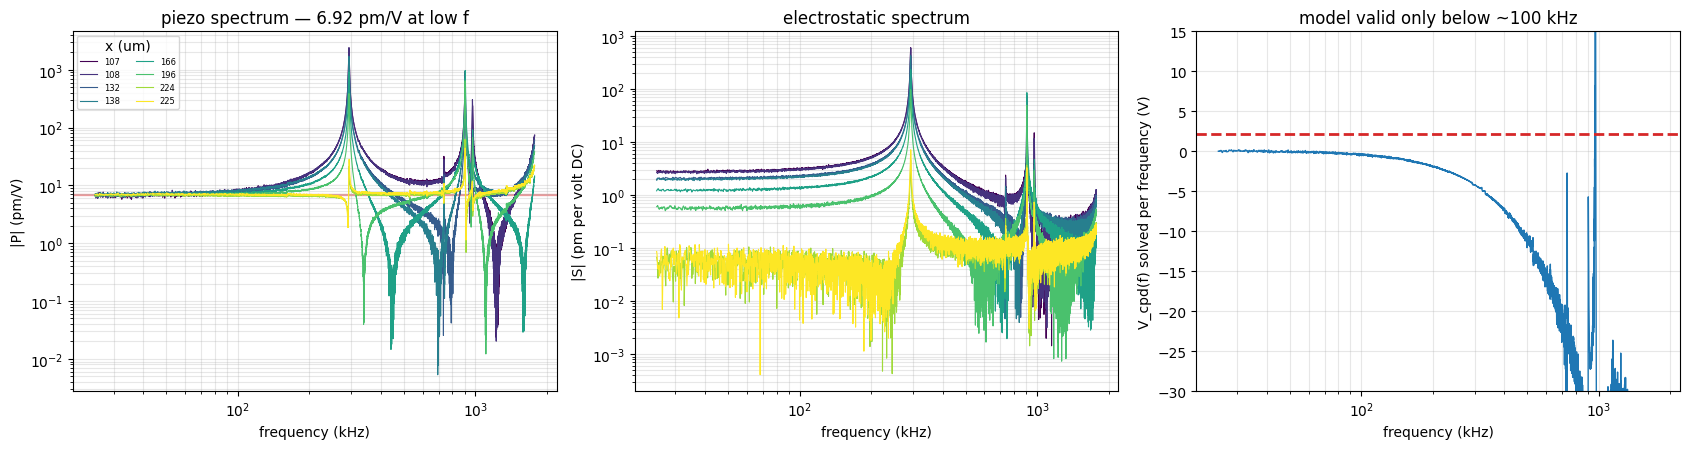

In [4]:
z = np.load(os.path.join(BIAS, 'Series_result.npz'), allow_pickle=True)
V, xm, F, Z = z['bias_V'], z['x_um'], z['freq_Hz'], z['Z']
order = [225., 166., 107., 132., 196., 224., 108., 138.]     # measurement order
DCm = {p: measured_invols(os.path.join(BIAS, f'FAMapS{2*k+1:04d}.ibw'))
       for k, p in enumerate(order)}
AC = np.array([DCm[p]/AC_DIVISOR for p in xm])

M = np.stack([np.ones(len(V)), V], 1)
Cf = np.linalg.lstsq(M, Z.reshape(len(V), -1), rcond=None)[0]
a, b = Cf[0].reshape(len(xm), -1), Cf[1].reshape(len(xm), -1)

QS = (F > 28.5e3) & (F < 50e3)                # quasi-static: the static shape is valid here
ref = None
A0, B0 = [], []
for i in range(len(xm)):
    aa, bb = a[i, QS].mean(), b[i, QS].mean()
    if ref is None: ref = bb/abs(bb)
    A0.append(np.real(aa*np.conj(ref))); B0.append(np.real(bb*np.conj(ref)))
u = np.array(A0)*AC*1e12; v = np.array(B0)*AC*1e12
VCPD, d_eff = np.linalg.lstsq(np.stack([v, -np.ones(len(u))], 1), -u, rcond=None)[0]
res = u + VCPD*v
print(f'V_cpd  = {VCPD:+.3f} V')
print(f'd_eff  = {d_eff:.2f} +- {res.std():.2f} pm/V   ({100*res.std()/res.mean():.0f}%)')
print(f'spread across positions: {u.max()/u.min():.1f}x before -> {res.max()/res.min():.2f}x after')
print(f'(the electrostatic weight varies {v.max()/v.min():.0f}x over the same positions)')

P = (a + VCPD*b)*AC[:, None]*1e12             # piezo,        pm per 1 V AC
Sp = b*AC[:, None]*1e12                       # electrostatic, pm per volt of DC offset
up, vp = P - P.mean(0), Sp - Sp.mean(0)
Vf = -np.real((up*np.conj(vp)).sum(0))/np.maximum((np.abs(vp)**2).sum(0), 1e-30)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6)); cm = plt.cm.viridis
for i in range(len(xm)):
    ax[0].loglog(F/1e3, np.abs(P[i]), lw=.8, color=cm(i/7), label=f'{xm[i]:.0f}')
    ax[1].loglog(F/1e3, np.abs(Sp[i]), lw=.8, color=cm(i/7))
ax[0].axhspan(d_eff-res.std(), d_eff+res.std(), color='C3', alpha=.35)
ax[0].set_ylabel('|P| (pm/V)'); ax[0].set_title(f'piezo spectrum — {d_eff:.2f} pm/V at low f')
ax[0].legend(fontsize=6, ncol=2, title='x (um)')
ax[1].set_ylabel('|S| (pm per volt DC)'); ax[1].set_title('electrostatic spectrum')
ax[2].semilogx(F/1e3, Vf, lw=1); ax[2].axhline(VCPD, color='C3', ls='--', lw=2)
ax[2].set_ylim(-30, 15); ax[2].set_ylabel('V_cpd(f) solved per frequency (V)')
ax[2].set_title('model valid only below ~100 kHz')
for A_ in ax: A_.set_xlabel('frequency (kHz)'); A_.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

## 4 · Uncertainty against the dense ground truth

The reported `std` is an OLS predictive error: per-frequency residual at the
measured points times spatial leverage. It cannot see run-to-run reproducibility,
which is what actually dominates.

reconstruction error vs dense : 9.5 +- 2.9 %
run-to-run reproducibility    : 9.6 +- 3.4 %
  -> reconstruction is at 0.99x the reproducibility floor

std calibration: median |E|/std = 2.72 (calibrated would be 0.83)
  within 1 std 11% (expect 71%), 2 std 34% (expect 98%)

convergence with the D-optimal acquisition order:


  n= 5  rank 3  map error  14.2 %
  n= 6  rank 4  map error  12.0 %


  n= 8  rank 5  map error  11.2 %


  n=10  rank 5  map error  10.3 %


  n=12  rank 5  map error   9.9 %


  n=16  rank 5  map error   9.5 %


  n=20  rank 5  map error   9.1 %


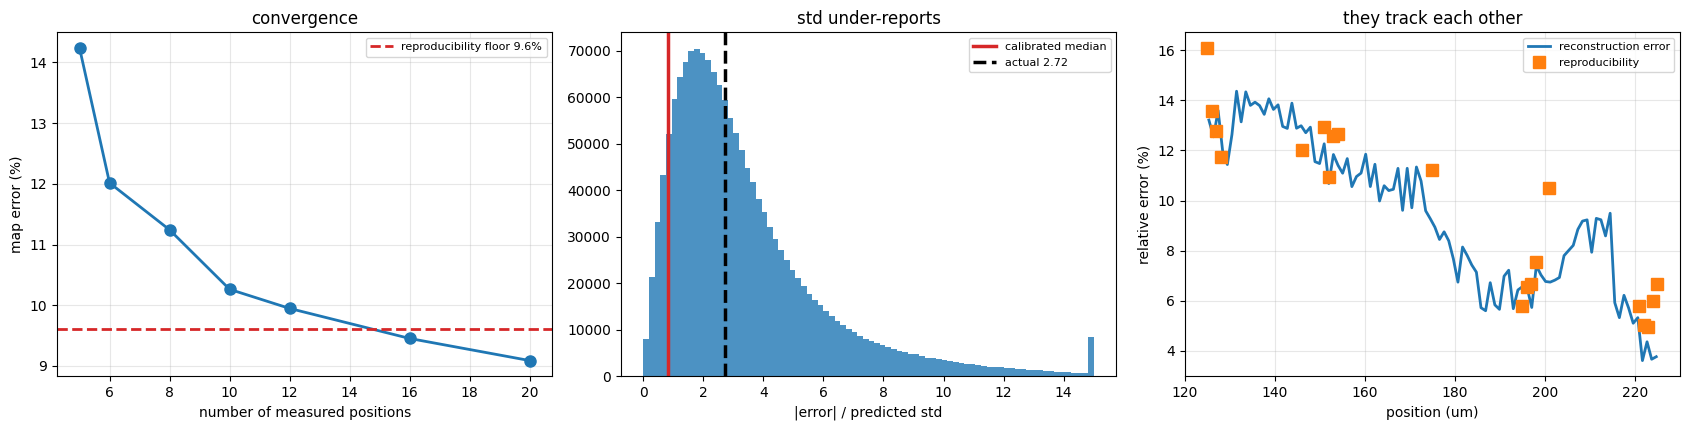

In [5]:
r = np.load(os.path.join(DENSE, 'ActiveModeMap_result.npz'), allow_pickle=True)
xg, Ff, mx, mZ = r['x_grid'], r['freq'], r['measured_x'], r['measured_Z']
dd = np.load(os.path.join(DENSE, 'DenseReference.npz'))
xd, Zd = dd['x_um'], dd['Z']
xdc = ps.apply(xd)
j = np.array([int(np.argmin(np.abs(xg - v))) for v in xdc])
keep = np.array([abs(xg[k] - v) < 0.6 for k, v in zip(j, xdc)])
jj, Zt = j[keep], Zd[keep]

sel = [int(np.argmin(np.abs(xg - v))) for v in mx]
o = reconstruct_map(xg, sel, mZ, 4)
E = o['Zrec'][jj] - Zt; St = o['std'][jj]; zsc = np.abs(E)/St
rel = 100*(np.abs(E).mean(1)/np.abs(Zt).mean(1))
rep = [100*np.abs(zi - Zd[int(np.argmin(np.abs(xdc-xi)))]).mean() /
       np.abs(Zd[int(np.argmin(np.abs(xdc-xi)))]).mean() for xi, zi in zip(mx, mZ)]
print(f'reconstruction error vs dense : {rel.mean():.1f} +- {rel.std():.1f} %')
print(f'run-to-run reproducibility    : {np.mean(rep):.1f} +- {np.std(rep):.1f} %')
print(f'  -> reconstruction is at {rel.mean()/np.mean(rep):.2f}x the reproducibility floor')
print(f'\nstd calibration: median |E|/std = {np.median(zsc):.2f} (calibrated would be 0.83)')
print(f'  within 1 std {100*(zsc<1).mean():.0f}% (expect 71%), 2 std {100*(zsc<2).mean():.0f}% (expect 98%)')

acq = read_log(os.path.join(DENSE, 'ActiveModeMap_log.csv')).position_x_um.values
om = [int(np.argmin(np.abs(mx - v))) for v in acq]          # TRUE acquisition order
mxA, mZA = mx[om], mZ[om]
print('\nconvergence with the D-optimal acquisition order:')
ns, errs = [], []
for n in (5, 6, 8, 10, 12, 16, 20):
    best = min(((rk, 100*(np.abs(reconstruct_map(xg, [int(np.argmin(np.abs(xg-v)))
                    for v in mxA[:n]], mZA[:n], rk)['Zrec'][jj]-Zt).mean(1)
                    / np.abs(Zt).mean(1)).mean()) for rk in (3, 4, 5) if rk+2 <= n),
               key=lambda t: t[1])
    ns.append(n); errs.append(best[1])
    print(f'  n={n:2d}  rank {best[0]}  map error {best[1]:5.1f} %')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
ax[0].plot(ns, errs, 'o-', ms=8, lw=2); ax[0].axhline(np.mean(rep), color='C3', ls='--', lw=2,
          label=f'reproducibility floor {np.mean(rep):.1f}%')
ax[0].set_xlabel('number of measured positions'); ax[0].set_ylabel('map error (%)')
ax[0].set_title('convergence'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].hist(np.clip(zsc.ravel(), 0, 15), bins=80, alpha=.8)
ax[1].axvline(0.83, color='C3', lw=2.5, label='calibrated median')
ax[1].axvline(np.median(zsc), color='k', ls='--', lw=2.5, label=f'actual {np.median(zsc):.2f}')
ax[1].set_xlabel('|error| / predicted std'); ax[1].set_title('std under-reports'); ax[1].legend(fontsize=8)
so = np.argsort(xdc[keep])
ax[2].plot(xdc[keep][so], rel[so], lw=2, label='reconstruction error')
ax[2].plot(mx, rep, 's', ms=8, label='reproducibility')
ax[2].set_xlabel('position (um)'); ax[2].set_ylabel('relative error (%)')
ax[2].set_title('they track each other'); ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

## Summary

| quantity | value |
|---|---|
| position scale, 1.0 µm pitch | 1.024 ± 0.004 (≈2 µm over 100 µm) |
| position scale, 0.5 µm pitch (Demo6) | 0.847 (≈15 µm over 100 µm) |
| detection | interferometric — x²(3L−x) fits 1/InvOLS to 0.33% |
| AC sensitivity | AmpInvOLS = InvOLS / 32.000 |
| V_cpd | +2.11 V (quasi-static solve) |
| d_eff | 6.92 ± 0.19 pm/V, 3% across 8 positions |
| reconstruction error | 9.5% = 0.99× the reproducibility floor |
| `std` calibration | under-reports ~3× |
| positions needed | 5 gives 14%, ≥16 reaches the floor |

**Open:** V_cpd from the quasi-static solve (+2.11 V) disagrees with the resonance
|Z| null (−1.9 V); an independent KPFM reading decides which. And the ×32 is
derived by Igor rather than measured — moving the force-curve drive frequency off
mode B (to ~600 kHz) would let `Amp_forcecurve`/`|Z|_tune` measure it directly.